# App Store Sales Spick Investigation and Debug Plan

 traffic spike with worse funnel
You’re given a dataset with 3 years of daily metrics for the App Store. You notice:

A large traffic spike that is not explained by normal seasonality.
Add-to-cart (ATC) rate drops sharply during the spike.
Conversion rate drops slightly.
Assume the table below (you may create derived fields like YoY, WoW, and rolling averages):

Table: daily_app_store_metrics
```
date (DATE)
sessions (INT) — total visits to the App Store
product_views (INT)
add_to_cart (INT)
purchases (INT)
revenue (NUMERIC)
channel (STRING) — e.g., organic, paid_search, email, affiliate, referral
device_type (STRING) — desktop/mobile/tablet
geo (STRING)
merchant_tier (STRING) — e.g., trial/basic/plus
landing_page (STRING)
app_category (STRING)
is_bot_suspected (BOOL) — if available
```

Tasks
1. List plausible hypotheses that could cause sessions ↑ while ATC rate ↓ and conversion ↓/flat (cover both product and data-quality causes).
2. Propose the most useful charts you would build (in Python or Google Sheets) to validate/refute your hypotheses.
3. Explain what follow-up data you would request if the dataset is insufficient.

Define rates as:
- ATC_rate = add_to_cart / product_views (or justify an alternative)
- CVR = purchases / sessions

Output expected: a structured investigation plan plus the key visualizations you’d generate.

# Read input file

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
raw_df = pd.read_csv("daily_app_store_metrics.csv")

In [2]:
from datetime import date

In [3]:
raw_df.head()

,date,sessions,product_views,add_to_cart,purchases,revenue,channel,device_type,geo,merchant_tier,landing_page,app_category,is_bot_suspected
0,2023-01-01,1084,1689,209,52,2492.60,organic,mobile,US,trial,home,finance,False
1,2023-01-01,833,1270,178,46,2264.34,organic,mobile,US,basic,home,productivity,False
2,2023-01-01,379,602,81,17,667.72,organic,mobile,US,plus,product_page,gaming,True
3,2023-01-01,228,359,47,12,529.78,organic,mobile,CA,trial,category_page,productivity,False
4,2023-01-01,166,274,31,8,435.09,organic,mobile,CA,basic,blog_article,finance,False


In [4]:
raw_df['act_rate'] = raw_df['add_to_cart']/raw_df['product_views']
raw_df['cvr'] = raw_df['purchases']/raw_df['sessions']

In [5]:
raw_df.shape

(414288, 15)

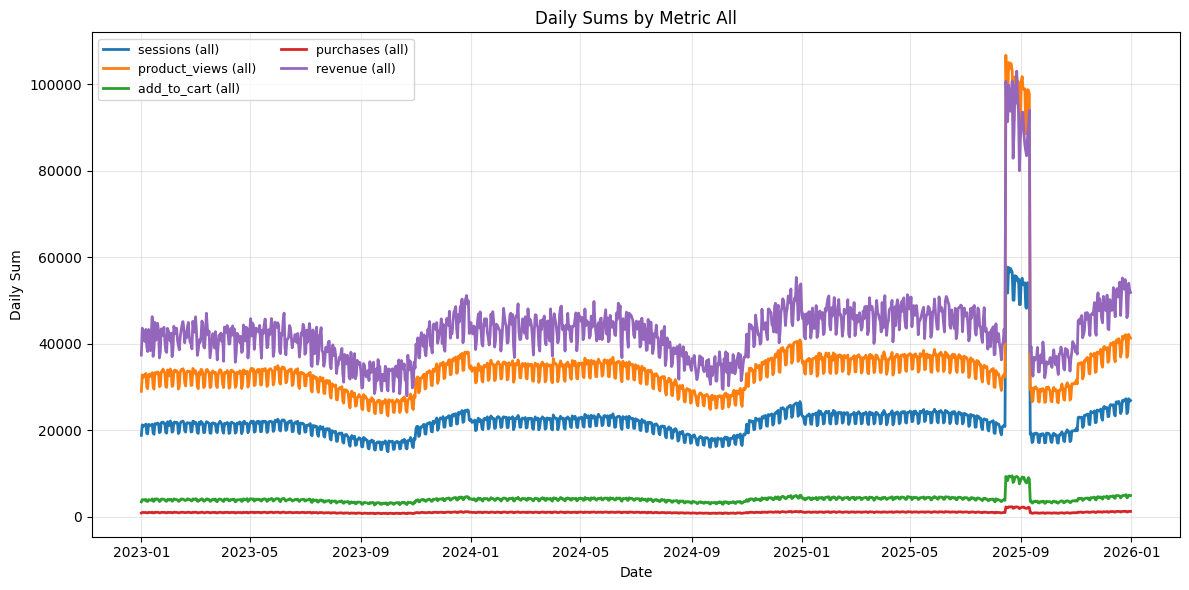

In [6]:
metrics = ["sessions", "product_views", "add_to_cart", "purchases", "revenue"]

# Ensure date is datetime
raw_df["date"] = pd.to_datetime(raw_df["date"])

# Daily sums (all rows)
daily_all = (
    raw_df.groupby("date", as_index=True)[metrics]
    .sum()
    .sort_index()
)

# Daily sums (non-bot only)
daily_nonbot = (
    raw_df.loc[~raw_df["is_bot_suspected"]]
    .groupby("date", as_index=True)[metrics]
    .sum()
    .sort_index()
)

# Plot
plt.figure(figsize=(12, 6))

for col in metrics:
    plt.plot(daily_all.index, daily_all[col], label=f"{col} (all)", linewidth=2)
    # plt.plot(daily_nonbot.index, daily_nonbot[col], linestyle="--", label=f"{col} (non-bot)", linewidth=2)

plt.title("Daily Sums by Metric All")
plt.xlabel("Date")
plt.ylabel("Daily Sum")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


In [7]:
daily_all.head()

,sessions,product_views,add_to_cart,purchases,revenue
date,,,,,
2023-01-01,18770,28970,3387,813,37350.22
2023-01-02,21194,32734,3906,946,43559.75
2023-01-03,20837,32121,3864,935,42909.15
2023-01-04,20996,32477,3898,935,41037.29
2023-01-05,21200,32896,3753,915,40460.52


In [8]:
# Ensure date column is datetime
daily_all = daily_all.reset_index()
daily_all["date"] = pd.to_datetime(daily_all["date"])


# Identify the Spike Window

In [9]:
dailly_all_filtered = daily_all.loc[daily_all['sessions'] >= 27000].copy()
dailly_all_filtered

,date,sessions,product_views,add_to_cart,purchases,revenue
957,2025-08-15,57978,106709,9262,2217,100670.25
958,2025-08-16,51739,95022,8658,2093,94162.05
959,2025-08-17,51710,95110,8300,2012,91346.55
960,2025-08-18,57641,105022,9317,2235,99824.60
961,2025-08-19,56511,103590,9357,2240,96761.33
962,2025-08-20,57401,104899,9150,2197,93758.37
963,2025-08-21,57027,104678,9271,2219,96849.20
964,2025-08-22,56495,103015,9416,2265,100735.26
965,2025-08-23,50039,91616,7872,1892,82876.54
966,2025-08-24,50026,91652,8152,1965,88685.38


In [10]:
spike_window = {'start_date': pd.to_datetime('2025-08-15'), 'end_date': pd.to_datetime('2025-09-10')}

In [11]:
spike_window

{'start_date': Timestamp('2025-08-15 00:00:00'),
 'end_date': Timestamp('2025-09-10 00:00:00')}

A flash sale of high priced products (like luxury bags)

1. Data Logging Issue
2. Bot Attach
3. Product Issues 
4. Mix-shift

## Bot?
No, non bot have same spike. Bot usually drive up non-payment Plus, bot doesn't contribute to Revenues.

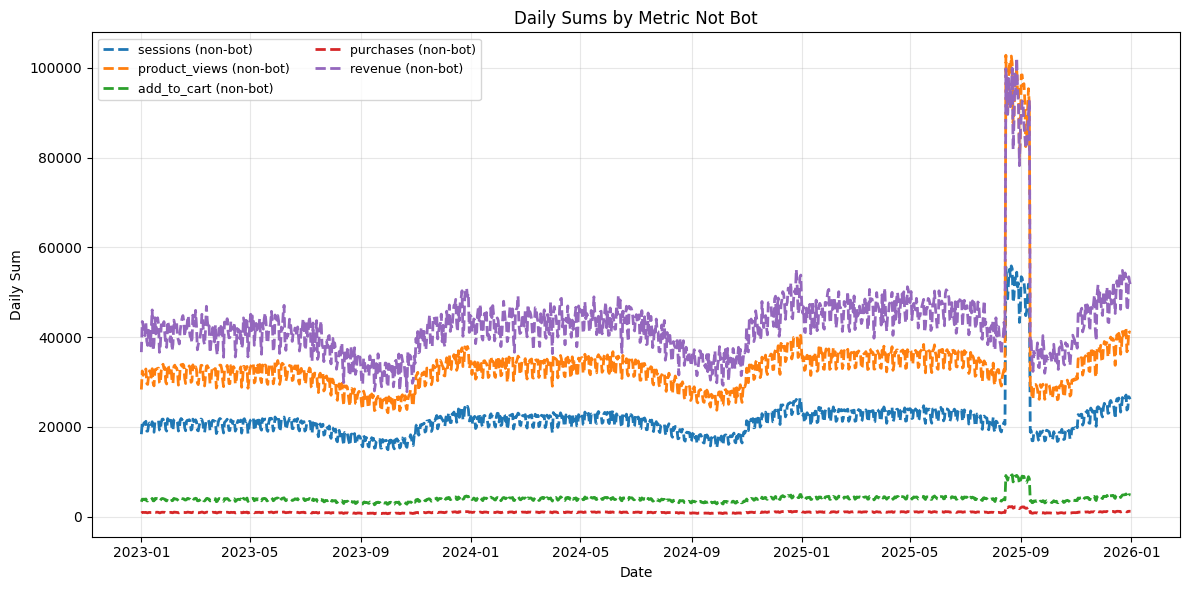

In [12]:
# Plot
plt.figure(figsize=(12, 6))

for col in metrics:
    #plt.plot(daily_all.index, daily_all[col], label=f"{col} (all)", linewidth=2)
    plt.plot(daily_nonbot.index, daily_nonbot[col], linestyle="--", label=f"{col} (non-bot)", linewidth=2)

plt.title("Daily Sums by Metric Not Bot")
plt.xlabel("Date")
plt.ylabel("Daily Sum")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

In [13]:
# spike_window = (start_date, end_date)
start_date = spike_window['start_date']
end_date = spike_window['end_date']

# Length of spike window in days (inclusive)
spike_days = (end_date - start_date).days + 1

# Build pre-window of equal length immediately before start_date
pre_start = start_date - pd.Timedelta(days=spike_days)
pre_end = start_date - pd.Timedelta(days=1)

raw_df["date"] = pd.to_datetime(raw_df["date"])

mask = (
    raw_df["date"].between(pre_start, pre_end)
    | raw_df["date"].between(start_date, end_date)
)

main_df = raw_df.loc[mask].copy()

In [14]:
main_df.head()

,date,sessions,product_views,add_to_cart,purchases,revenue,channel,device_type,geo,merchant_tier,landing_page,app_category,is_bot_suspected,act_rate,cvr
351540,2025-07-19,1248,1965,263,66,3435.43,organic,mobile,US,trial,category_page,finance,False,0.133842,0.052885
351541,2025-07-19,951,1493,208,51,2126.86,organic,mobile,US,basic,home,lifestyle,False,0.139317,0.053628
351542,2025-07-19,444,649,99,22,1371.90,organic,mobile,US,plus,product_page,finance,True,0.152542,0.049550
351543,2025-07-19,246,388,45,11,319.44,organic,mobile,CA,trial,category_page,education,False,0.115979,0.044715
351544,2025-07-19,177,288,37,9,282.04,organic,mobile,CA,basic,home,gaming,False,0.128472,0.050847


In [15]:
from ast import main


main_df["date"] = pd.to_datetime(main_df["date"])

# Daily aggregates
main_daily_agg = (
    main_df
    .groupby(main_df["date"].dt.date, as_index=True)[
        ["sessions", "product_views", "add_to_cart", "purchases", "revenue"]
    ]
    .sum()
)
def conversions_metrics(main_daily_agg):
    # Conversion rates (safe divide)
    main_daily_agg["pv_per_session"] = main_daily_agg["product_views"] / main_daily_agg["sessions"].replace(0, np.nan)
    main_daily_agg["atc_per_pv"] = main_daily_agg["add_to_cart"] / main_daily_agg["product_views"].replace(0, np.nan)
    main_daily_agg["purchase_per_atc"] = main_daily_agg["purchases"] / main_daily_agg["add_to_cart"].replace(0, np.nan)
    main_daily_agg["revenue_per_atc"] = main_daily_agg["revenue"] / main_daily_agg["add_to_cart"].replace(0, np.nan)
    # Spike window flag
    main_daily_agg = main_daily_agg.reset_index()
    return main_daily_agg

main_daily_agg = conversions_metrics(main_daily_agg)


In [16]:
start_date

Timestamp('2025-08-15 00:00:00')

revenue_per_act is flat, it's not high-price product,.

the downstream of the funnel is consistent: add to cart -> puchase -> revenue 
the uppder funnel session -> product views -> add to cart, act_per_pv is down 20%

In [17]:
main_daily_agg

,date,sessions,product_views,add_to_cart,purchases,revenue,pv_per_session,atc_per_pv,purchase_per_atc,revenue_per_atc
0,2025-07-19,20711,32095,3832,923,41564.91,1.549660,0.119396,0.240866,10.846793
1,2025-07-20,20101,31097,3672,870,40259.63,1.547037,0.118082,0.236928,10.963952
2,2025-07-21,22429,34727,4152,994,45648.94,1.548308,0.119561,0.239403,10.994446
3,2025-07-22,22609,35006,4231,1034,48327.06,1.548321,0.120865,0.244387,11.422137
4,2025-07-23,22404,34568,4018,968,42876.59,1.542939,0.116235,0.240916,10.671127
5,2025-07-24,22366,34455,4118,995,43576.83,1.540508,0.119518,0.241622,10.582037
6,2025-07-25,22432,34713,4016,966,42436.90,1.547477,0.115692,0.240538,10.566957
7,2025-07-26,20235,31368,3727,891,38717.11,1.550185,0.118815,0.239066,10.388277
8,2025-07-27,19785,30692,3665,884,40707.47,1.551276,0.119412,0.241201,11.107086
9,2025-07-28,21792,33564,3985,956,42657.76,1.540198,0.118728,0.239900,10.704582


need a charts to demo pre-post box plot
the 20% drop in act_per_pv is more likely to be Mix shift (low purchase intent sessions? or act doesn't grow as much as sessions growth)
promotion calendar


In [20]:
landing_pag_agg_df.head()

,date,landing_page,sessions
0,2025-07-19,blog_article,544
1,2025-07-19,campaign_lp,5742
2,2025-07-19,category_page,6275
3,2025-07-19,home,2633
4,2025-07-19,product_page,5517


In [23]:
landing_pag_agg_df.landing_page.unique()

array(['blog_article', 'campaign_lp', 'category_page', 'home',
       'product_page'], dtype=object)

# stacked area for Mix Shift checking
1. landing_page, no
2. channel, no
3. mobile, no, big spike in Mobile, but not distribution shift
4. geo, no, 
5. merchant_tier, no
6. app_category, no

In [27]:
main_df.columns

Index(['date', 'sessions', 'product_views', 'add_to_cart', 'purchases',
       'revenue', 'channel', 'device_type', 'geo', 'merchant_tier',
       'landing_page', 'app_category', 'is_bot_suspected', 'act_rate', 'cvr'],
      dtype='object')

In [46]:
agg_column = 'app_category'
agg_df = main_df[[agg_column,'sessions', 'date']].groupby(['date',agg_column]).sum('session').reset_index()	

/var/folders/4k/j__d3gw141bg1w632wmb538c0000gn/T/ipykernel_3148/4099343424.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab20", len(types))


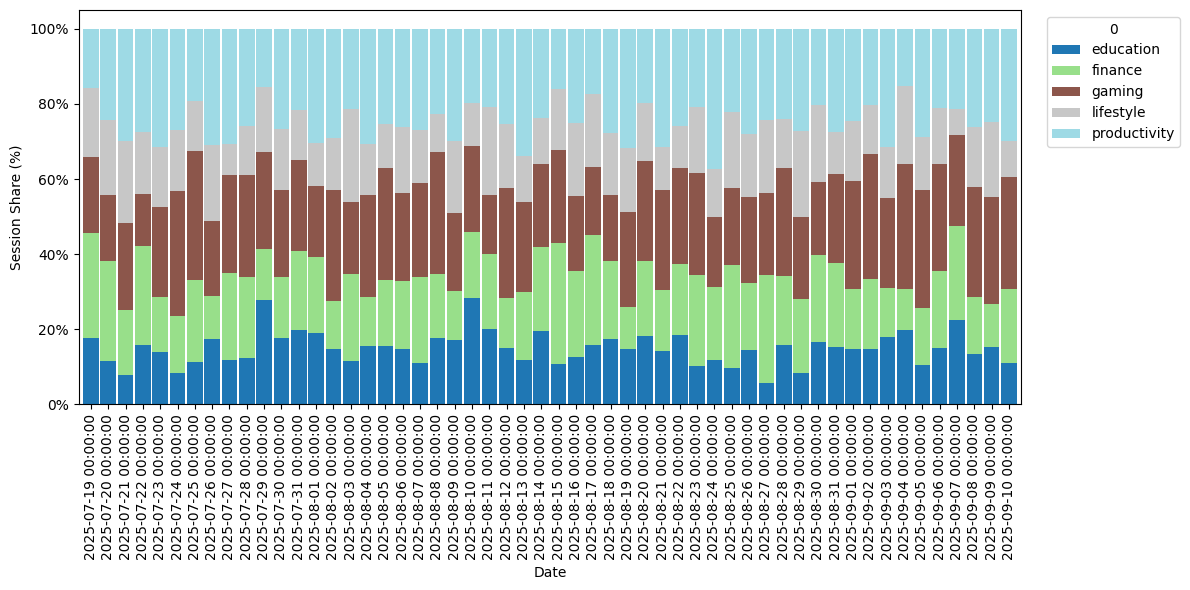

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Adjust these if your column names differ
date_col = "date"
type_col = agg_column
value_col = "sessions"  # total sessions

df = agg_df.copy()
df[date_col] = pd.to_datetime(df[date_col])

# Pivot to date x landing_page_type
pivot = (
    df.pivot_table(index=date_col, columns=type_col, values=value_col, aggfunc="sum", fill_value=0)
      .sort_index()
)

# Convert to percent of total per date
pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Consistent colors across dates
types = pct.columns.tolist()
cmap = plt.cm.get_cmap("tab20", len(types))
colors = {t: cmap(i) for i, t in enumerate(types)}

ax = pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=[colors[t] for t in types],
    width=0.9
)

ax.set_xlabel("Date")
ax.set_ylabel("Session Share (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title=f"{0}".format(agg_column), bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


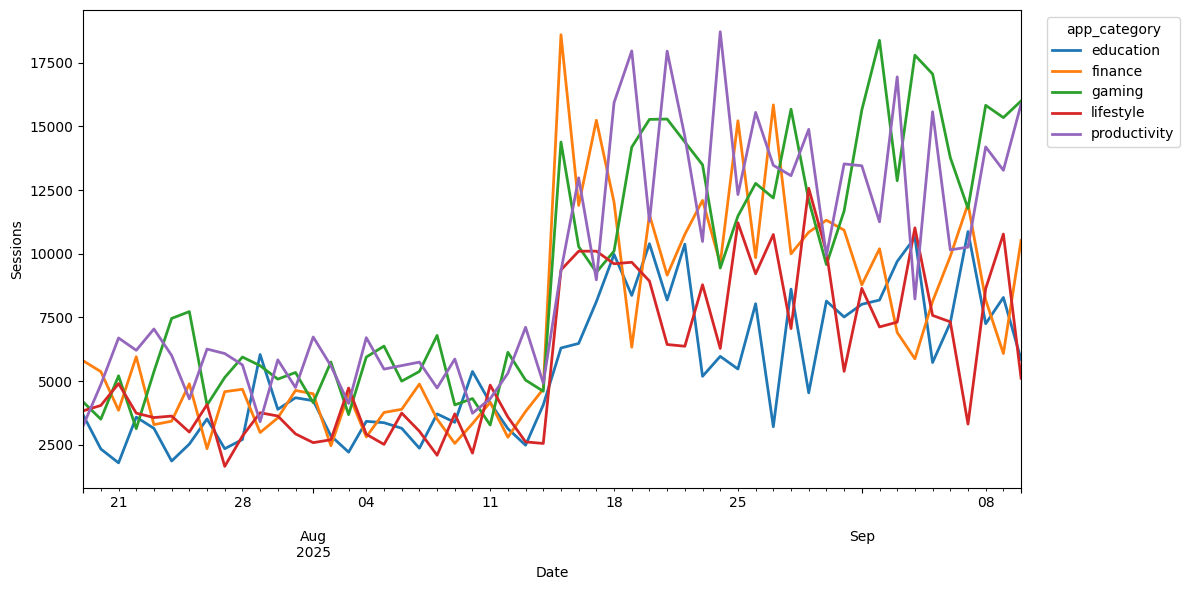

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# Adjust these if your column names differ
date_col = "date"
type_col = agg_column
value_col = "sessions"

df = agg_df.copy()
df[date_col] = pd.to_datetime(df[date_col])

# Pivot to date x landing_page_type for line chart
pivot = (
    df.pivot_table(index=date_col, columns=type_col, values=value_col, aggfunc="sum", fill_value=0)
      .sort_index()
)

ax = pivot.plot(figsize=(12, 6), linewidth=2)
ax.set_xlabel("Date")
ax.set_ylabel("Sessions")
ax.legend(title=f"{agg_column}", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


Below is a **Shopify-style “structured investigation plan”** you can basically read aloud in the interview. It’s optimized for speed + clarity: **sanity → localize → explain with mix/quality/product → decide next steps**.

---

## 0) Setup: define the spike window + derived fields

**Goal:** isolate “spike period” vs baseline.

* Identify spike dates using:

  * `sessions_z = (sessions - rolling_mean_28) / rolling_std_28`
  * Spike window = consecutive days where `sessions_z > 3` (or top 1% of sessions)
* Create derived fields:

  * `ATC_rate = add_to_cart / product_views` (given)
  * `PV_per_session = product_views / sessions`
  * `CVR = purchases / sessions` (given)
  * `PV_CVR = purchases / product_views` (purchase-per-view; useful because ATC is per view)
  * `Checkout_rate = purchases / add_to_cart` (downstream friction indicator)
  * YoY / WoW: `metric / metric.shift(365)` and `metric / metric.shift(7)`
  * Rolling averages: 7d and 28d

**Quick intuition check:** if sessions spike but **PV_per_session collapses**, that points to **low-intent traffic or bots** (or landing-page mismatch). If PV_per_session stays stable but ATC_rate drops, think **app mix / UX / pricing / tracking**.

---

## 1) Hypotheses: sessions ↑ while ATC_rate ↓ and CVR ↓/flat

I’d present these in buckets (they like structured thinking).

### A) Mix shift / low-intent traffic (most common)

1. **Channel mix shift**: spike comes from a channel that brings browsing/low purchase intent (affiliate/referral/paid social mis-targeted, etc.).
2. **Geo mix shift**: surge from regions with lower purchasing power, language mismatch, or limited payment support.
3. **Device mix shift**: surge mobile traffic where ATC UX is worse (sticky CTA hidden, slower load, etc.).
4. **Landing page mix shift**: spike driven to non-shopping pages (category pages, editorial, search results) → views don’t translate to cart.
5. **App category mix shift**: spike in categories that get viewed a lot but installed/purchased less (e.g., free tools browsing, seasonal curiosity).
6. **Merchant tier mix shift**: spike dominated by trial/new merchants who are less likely to buy paid apps.

### B) Bots / traffic quality / measurement noise

7. **Bot/crawler spike**: sessions inflated; bots may generate views but not real ATC/purchases.
8. **Duplicate counting / instrumentation change**: sessions definition changed (new tracking), inflating sessions but leaving downstream events unchanged → CVR falls mechanically.
9. **Event drop / tracking break for add_to_cart**: ATC event stopped firing correctly (frontend change, consent gating, ad blocker impact) → ATC_rate drops even if behavior didn’t.
10. **Attribution / channel tagging bug**: spike “moved” traffic into wrong channel bucket; downstream events not linked.

### C) Product / UX / performance regression

11. **Performance regression during spike** (latency, errors): users bounce before ATC; conversion slightly down.
12. **UI/CTA regression**: ATC button less visible, variant/experiment shipped, or new layout reduces add-to-cart.
13. **Pricing/policy change**: more apps require approval/payment steps; discourages ATC.
14. **Inventory/eligibility constraints**: certain apps not available for certain geos/tiers → views without ability to add to cart.

### D) Funnel math / definition mismatch

15. **ATC denominator changed**: product_views definition broadened (e.g., “impression” counted as view) → ATC_rate appears to drop.

---

## 2) The most useful charts to validate/refute (what I’d build)

You want charts that **localize the issue** (when/where) and **separate mix vs true behavior change**.

### Chart Set 1 — Global time series (find the “what changed”)

1. **Time series (3y daily)** with spike window shaded:

   * sessions, product_views, add_to_cart, purchases (levels)
2. **Time series of rates** (with 7d rolling):

   * PV_per_session, ATC_rate, Checkout_rate, CVR, PV_CVR
     **Interpretation:**

* If **PV_per_session drops** → low-intent/bots/landing mismatch.
* If **ATC_rate drops but Checkout_rate stable** → ATC-specific (UX/tracking) rather than checkout friction.
* If **Checkout_rate drops** → checkout/payment/eligibility issue.

### Chart Set 2 — Contribution / decomposition (is it mix shift?)

3. **Stacked area (share of sessions) by channel** over time + overlay total sessions

4. Same for **device_type**, **geo (top N)**, **landing_page (top N)**, **merchant_tier**, **app_category**
   **Interpretation:** look for a sharp share jump aligned with spike.

5. **Rate-by-segment time series** (small multiples) during baseline vs spike:

   * ATC_rate by channel
   * CVR by channel
   * PV_per_session by channel
     **Interpretation:** identifies whether the drop is concentrated in new dominant segments.

### Chart Set 3 — Counterfactual “mix-adjusted” metrics (prove mix shift vs real regression)

6. **Mix-adjusted ATC_rate**: hold baseline weights constant.

   * Compute baseline segment weights (e.g., channel share pre-spike)
   * Compute expected ATC_rate during spike using baseline weights × spike segment rates
     If observed drop ≈ expected drop → mostly mix shift.
     If observed drop is worse → within-segment behavioral/UX/tracking issue.

### Chart Set 4 — Bot / data-quality checks

7. If `is_bot_suspected` exists:

   * sessions split by `is_bot_suspected` (levels + share)
   * ATC_rate/CVR for bot vs non-bot traffic
8. **Ratio sanity plots**:

   * product_views vs sessions scatter (spike points highlighted)
   * add_to_cart vs product_views scatter
     **Interpretation:** bots often show abnormal ratios/clusters.

### Chart Set 5 — Landing page & pathing (if available)

9. **Top landing pages during spike vs baseline** (bar chart: share of sessions)
10. **Funnel by landing page** (ATC_rate and PV_per_session)
    **Interpretation:** marketing deep link to informational pages can spike sessions but depress ATC.

---

## 3) Follow-up data I’d request (if this table alone isn’t enough)

I’d ask for data in three groups: **traffic drivers, tracking changes, UX/performance**.

### A) Traffic drivers / context

* **Campaign calendar**: paid campaigns, influencer/affiliate pushes, email blasts, partnerships, PR mentions
* **Channel definitions & tagging rules** (any changes during spike)
* **Referrer URLs / UTM breakdown** (within channel)
* **New app launches / featured placements** (homepage promos, collections)

### B) Measurement integrity

* **Event instrumentation changelog** (sessions/product_views/ATC/purchase definitions)
* **Client vs server events** (are purchases server-side? is ATC client-side?)
* **Consent/ATT/cookie gating changes** (especially affecting ATC events)
* **Bot detection logic** + raw bot signals (UA strings, IP rate limits, known crawlers)
* **Deduping rules** for sessions and events (did they change?)

### C) Product / UX / reliability

* **Page performance metrics**: load time, error rates, API latency by page type, device, geo
* **Experiment flags** running during spike (A/B tests, rollout logs)
* **Checkout/payment failure rates**, app install/payment eligibility constraints by geo/tier
* **Search quality / relevance metrics** if spike is search-driven

---

## 4) What I’d conclude / recommend (decision-ready outcomes)

I’d explicitly branch:

* **If it’s mostly mix shift (channel/geo/device) with stable within-segment rates:**
  → Work with Growth/Marketing to refine targeting, landing pages, and messaging.
  → Add monitoring: mix-adjusted ATC/CVR dashboards + alerting.

* **If it’s tracking break (ATC event drop only; other behavior stable):**
  → Treat as SEV for analytics integrity; validate with server-side logs; backfill if possible.

* **If it’s bot-driven:**
  → Filter bots from KPI dashboards, tighten bot detection, protect attribution & reporting.

* **If within-segment ATC drops across the board + performance regresses:**
  → Partner with Eng to investigate latency/errors; roll back relevant changes; prioritize mobile UX.

---

## 60-second talk track (to practice)

“First I’ll pin down the spike window and compute rolling averages plus PV/session, ATC_rate, CVR, and checkout_rate. Then I’ll decompose by channel/device/geo/landing page to see if this is a mix shift. If the drop is explained by mix, we optimize acquisition and landing. If not, I’ll look for within-segment drops pointing to UX/performance or tracking breaks—especially ATC instrumentation. Finally I’ll request campaign calendars, instrumentation changelogs, and performance/experiment logs to confirm root cause and recommend either targeting fixes, measurement fixes, bot filtering, or product rollback.”

If you want, tell me whether you’ll practice in **Google Sheets or Python**, and I’ll give you a **concrete chart checklist with formulas (Sheets) or a plotting skeleton (Python)** tailored to this exact table.
